In [1]:
import keras
keras.__version__

Using TensorFlow backend.


'2.1.2'

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [3]:
#restrict ourselves to top 10000 most frequent words
max([max(sequence) for sequence in train_data])

9999

In [4]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
# We reverse it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
# We decode the review; note that our indices were offset by 3
# because 0, 1 and 2 are reserved indices for "padding", "start of sequence", and "unknown".
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [5]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)

In [6]:
#test 
x_train[0]

array([ 0.,  1.,  1., ...,  0.,  0.,  0.])

In [7]:
# Vectorize labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

Building the network

In [8]:
#define the model
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation = 'relu', input_shape = (10000,)))
model.add(layers.Dense(16, activation = 'relu'))
model.add(layers.Dense(1, activation = 'sigmoid'))

In [9]:
#configure the model 
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [10]:
from keras import optimizers

model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [11]:
from keras import losses
from keras import metrics

model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

validating your approach


In [12]:
#setting aside a validation test
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [13]:
#train the model
history = model.fit(partial_x_train, 
                   partial_y_train, 
                   epochs = 20,
                   batch_size = 512, 
                   validation_data = (x_val, y_val))

Train on 15000 samples, validate on 10000 samples
Epoch 1/20
15000/15000 [==============================] - 11s 705us/step - loss: 0.5063 - binary_accuracy: 0.7855 - val_loss: 0.3785 - val_binary_accuracy: 0.8697
Epoch 2/20
15000/15000 [==============================] - 4s 248us/step - loss: 0.2994 - binary_accuracy: 0.9049 - val_loss: 0.3000 - val_binary_accuracy: 0.8902
Epoch 3/20
15000/15000 [==============================] - 3s 184us/step - loss: 0.2172 - binary_accuracy: 0.9287 - val_loss: 0.3088 - val_binary_accuracy: 0.8711
Epoch 4/20
15000/15000 [==============================] - 3s 181us/step - loss: 0.1746 - binary_accuracy: 0.9437 - val_loss: 0.2840 - val_binary_accuracy: 0.8840
Epoch 5/20
15000/15000 [==============================] - 3s 170us/step - loss: 0.1422 - binary_accuracy: 0.9543 - val_loss: 0.2858 - val_binary_accuracy: 0.8859
Epoch 6/20
15000/15000 [==============================] - 2s 165us/step - loss: 0.1147 - binary_accuracy: 0.9653 - val_loss: 0.3113 - val_b

In [14]:
history_dict = history.history

In [15]:
history_dict.keys()

dict_keys(['binary_accuracy', 'val_binary_accuracy', 'val_loss', 'loss'])

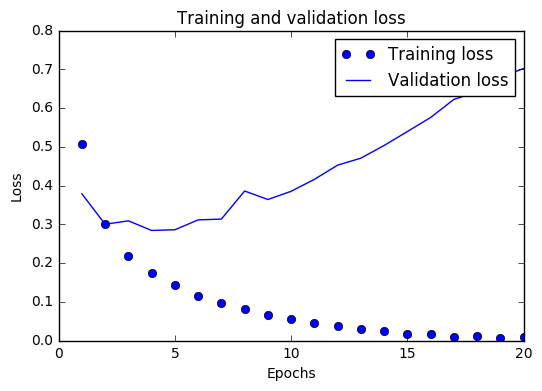

In [16]:
#plotting the training and validation loss
import matplotlib.pyplot as plt

acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

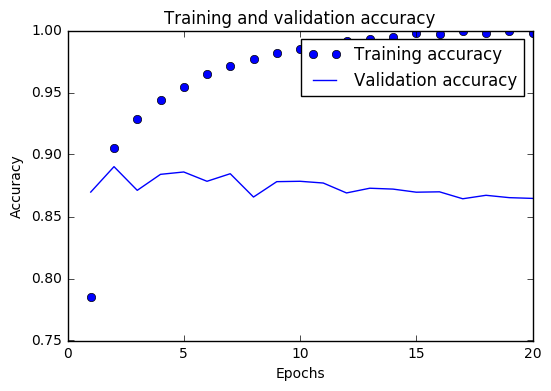

In [17]:
# "bo" is for "blue dot"
plt.plot(epochs,acc , 'bo', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [19]:
#predict on new data
model.predict(x_test)

array([[ 0.00851395],
       [ 0.99999988],
       [ 0.79849529],
       ..., 
       [ 0.00150318],
       [ 0.01197003],
       [ 0.7167716 ]], dtype=float32)